# Analyse exploratoire des données utiles
Données provenant des csv créés dans le fichier ``create_csv.ipynb``

In [175]:
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import importlib
import numpy as np

import functions_eda   # fichier python contenant les fonctions utiles à l'EDA

In [176]:
# Lecture des deux csv créés
train_audio = pd.read_csv("./eda_csv/train_audio_metadata.csv")
soundscapes = pd.read_csv("./eda_csv/soundscapes_metadata.csv")

In [177]:
train_audio.describe()

,duration
count,35549.000000
mean,34.882604
std,74.861285
min,0.008000
25%,10.788562
50%,21.000000
75%,39.837313
max,6881.097000


In [178]:
train_audio.info()

<class 'pandas.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   filename    35549 non-null  str    
 1   species_id  35549 non-null  str    
 2   duration    35549 non-null  float64
 3   filepath    35549 non-null  str    
 4   MFCC        35549 non-null  str    
dtypes: float64(1), str(4)
memory usage: 1.4 MB


In [179]:
soundscapes.describe()

,filename,filepath,MFCC
count,1478,1478,1478
unique,66,66,66
top,BC2026_Train_0039_S22_20211231_201500.ogg,data/train_soundscapes/BC2026_Train_0039_S22_2...,[-183.58652 39.8234 -103.10475 27.2...
freq,24,24,24


In [180]:
soundscapes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  1478 non-null   str  
 1   filepath  1478 non-null   str  
 2   MFCC      1478 non-null   str  
dtypes: str(3)
memory usage: 34.8 KB


## Skewness de la durée

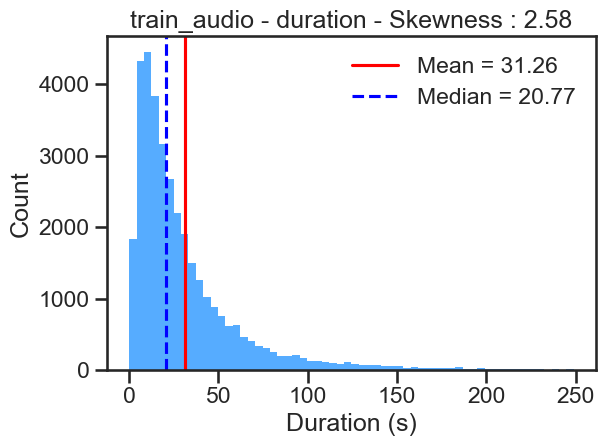

In [181]:
functions_eda.show_skewness(train_audio["duration"], "train_audio", "duration", "Duration (s)", max_value=250)  # max_value à 250 pour éliminer les outliers

In [182]:
# Première ligne de train_audio
first_line = train_audio.iloc[0]

audio_path = first_line["filepath"]

In [183]:
importlib.reload(functions_eda)

<module 'functions_eda' from 'd:\\ML\\ML_Project\\functions_eda.py'>

### Waveplot

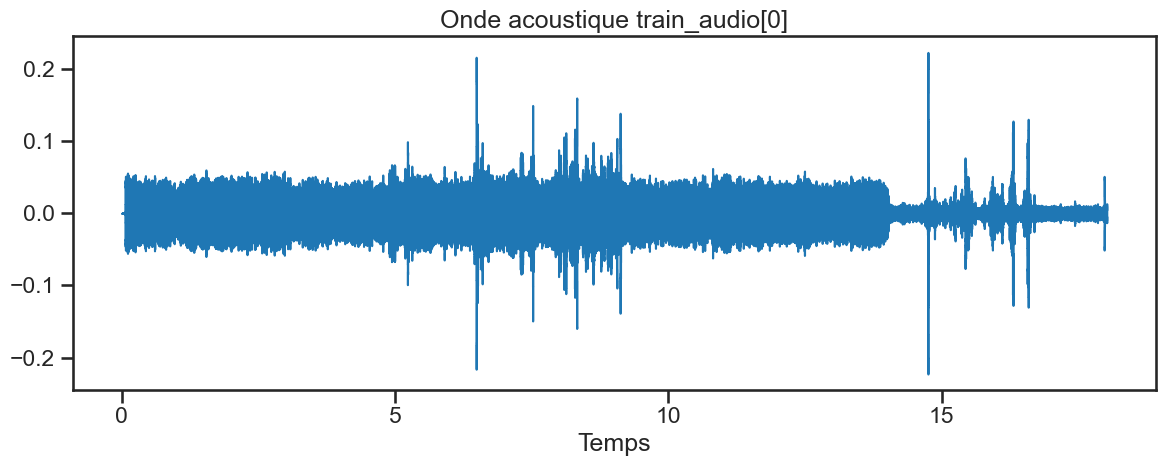

In [184]:
functions_eda.waveshow(audio_path, "train_audio[0]")

### Spectogramme

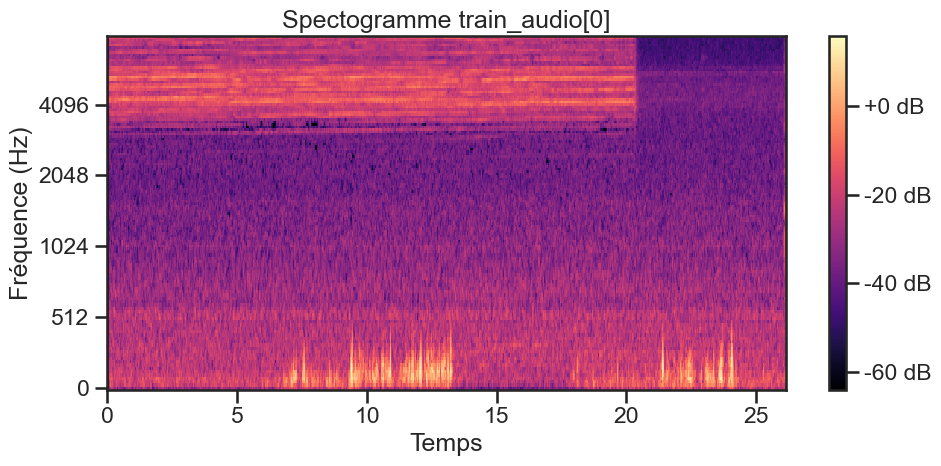

In [185]:
functions_eda.specshow(audio_path, "train_audio[0]")

### MFCC

In [186]:
importlib.reload(functions_eda)

<module 'functions_eda' from 'd:\\ML\\ML_Project\\functions_eda.py'>

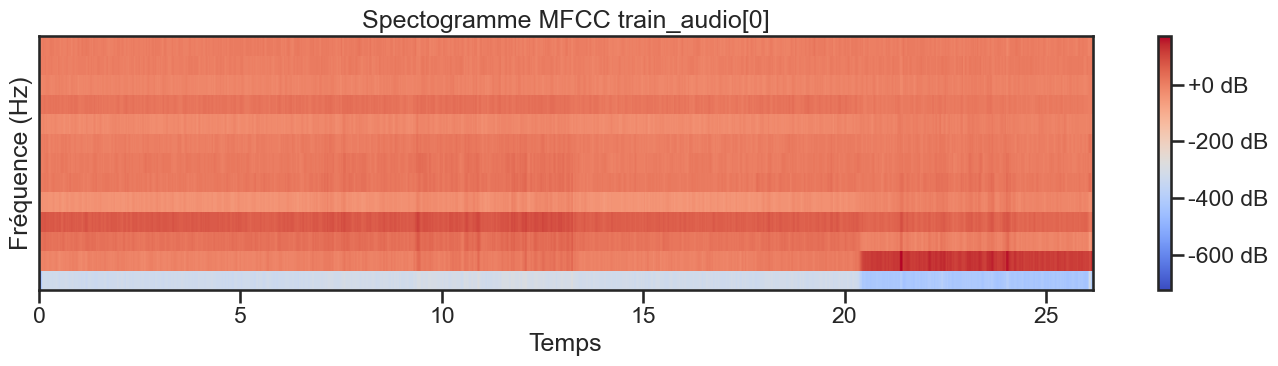

In [187]:
functions_eda.specshow_mfcc(audio_path, "train_audio[0]")

### Comparaison de MFCC pour chaque famille

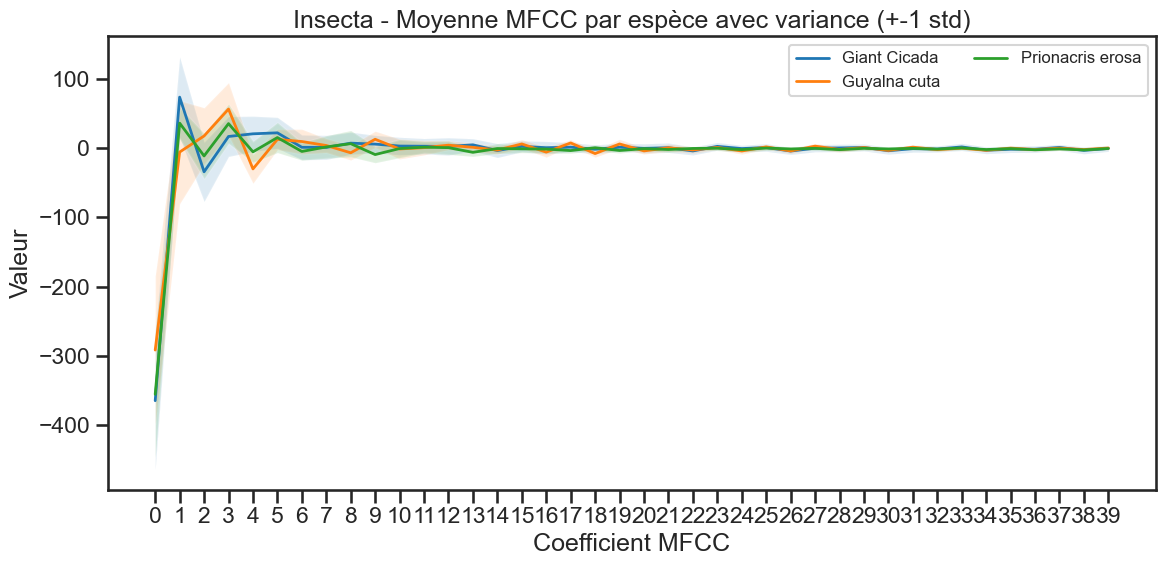

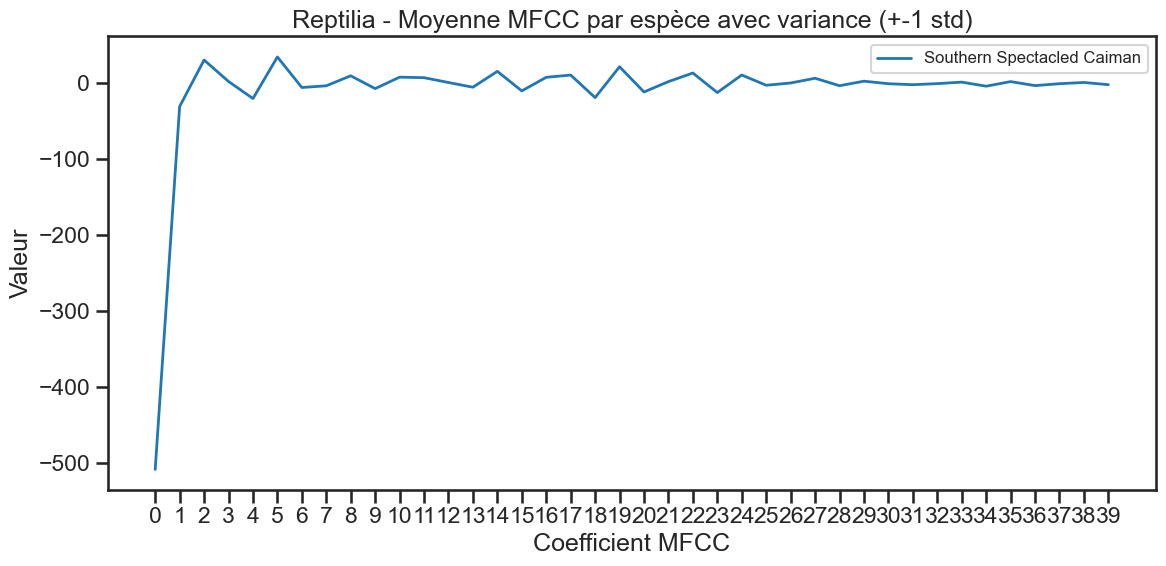

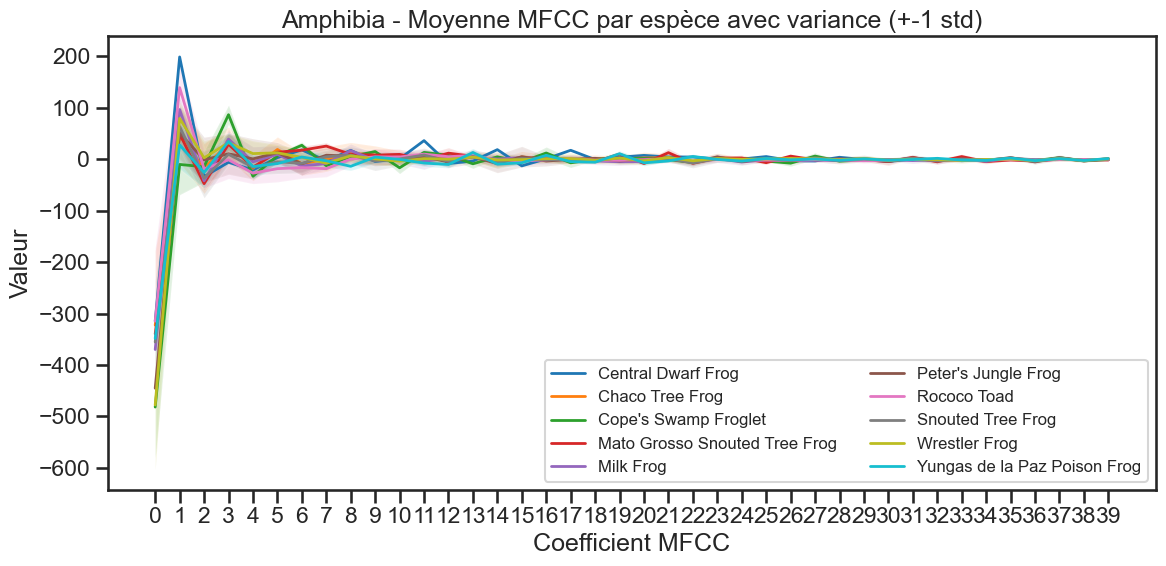

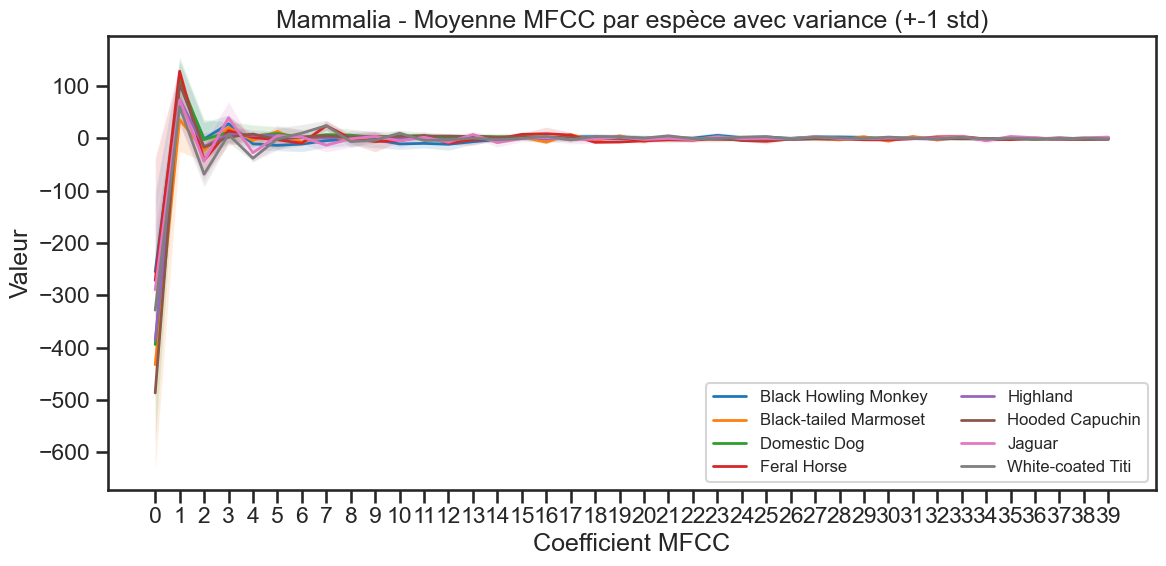

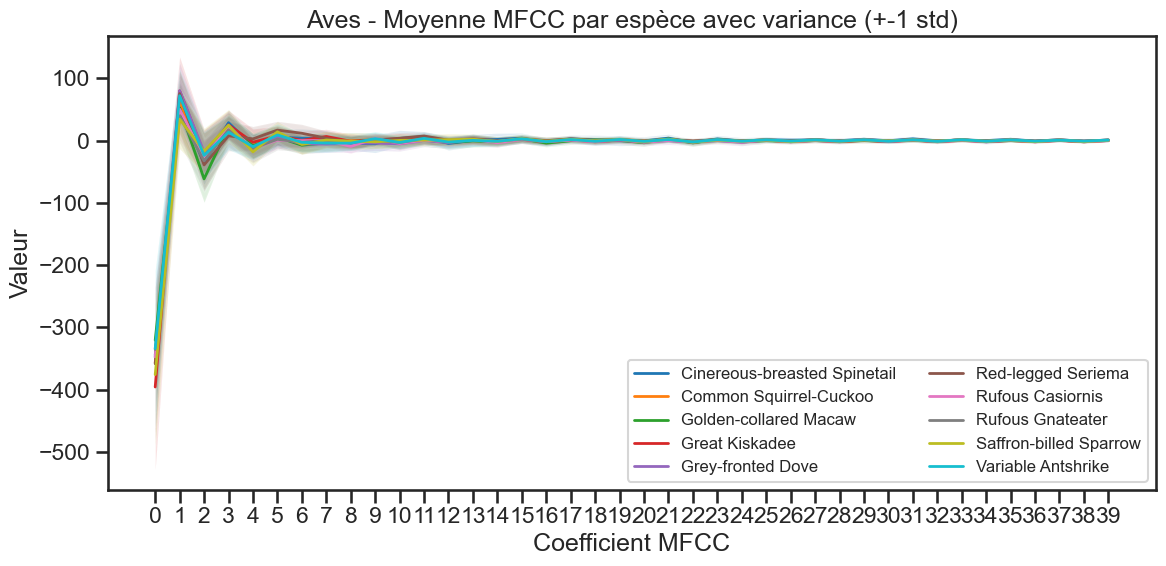

In [188]:
taxonomy = pd.read_csv("data/taxonomy.csv")

# Ajout d'une colonne de noms communs des espèces pour l'affichage
train_audio_common_name = train_audio.copy()
common_name_map = taxonomy.set_index("primary_label")["common_name"].to_dict()
train_audio_common_name["common_name"] = train_audio_common_name["species_id"].map(common_name_map)
train_audio_common_name = train_audio_common_name.dropna(subset=["common_name"])


for family in taxonomy["class_name"].unique():
    species_id_family = taxonomy.loc[taxonomy["class_name"] == family]["primary_label"].tolist()
    family_species_id = train_audio_common_name.loc[train_audio_common_name["species_id"].isin(species_id_family)]
    functions_eda.compare_mfcc(family_species_id, "common_name", "espèce", family)

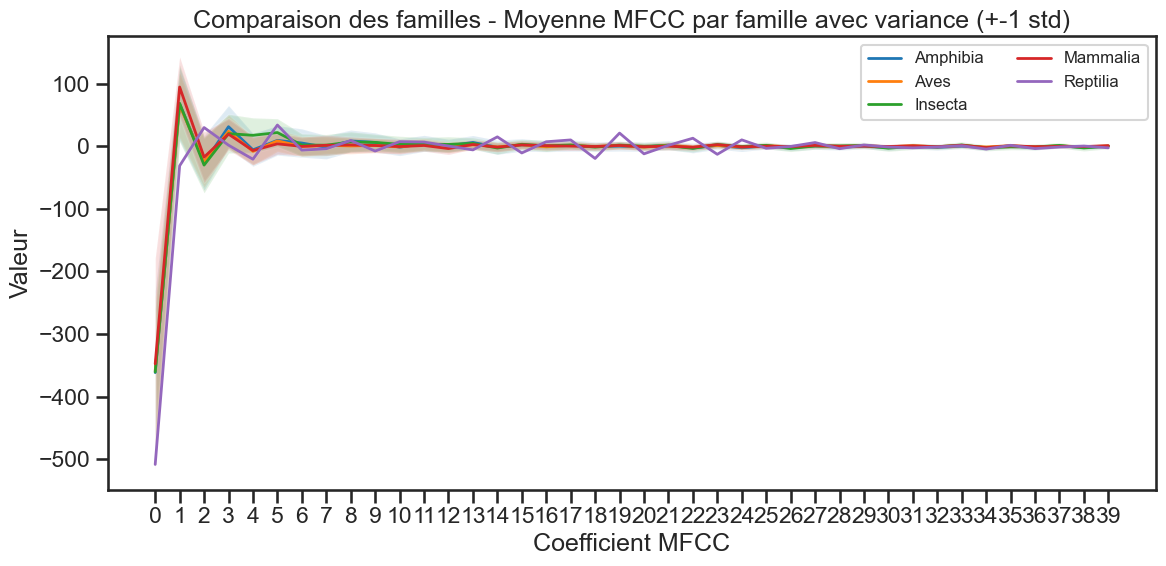

In [189]:
# Ajout d'une colonne famille
train_audio_family = train_audio.copy()
family_map = taxonomy.set_index("primary_label")["class_name"].to_dict()
train_audio_family["class_name"] = train_audio_family["species_id"].map(family_map)
train_audio_family = train_audio_family.dropna(subset=["class_name"])

functions_eda.compare_mfcc(train_audio_family, "class_name", "famille", "Comparaison des familles")

## Analyse des metadata sur les différentes espèces

### Train audio

In [190]:
species = train_audio["species_id"].unique()
print("Nombre d'espèces :", len(species))

Nombre d'espèces : 206


In [191]:
value_count_species = train_audio["species_id"].value_counts()

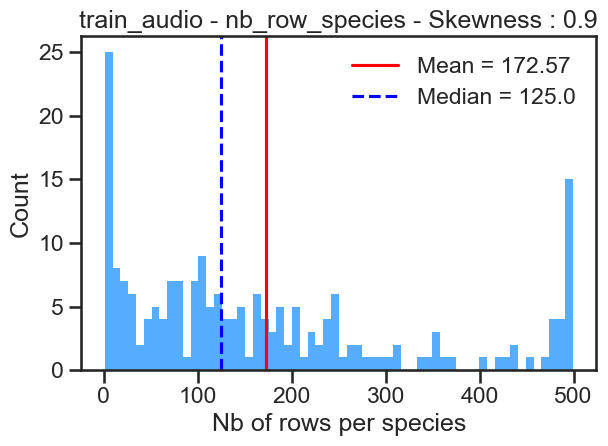

In [192]:
functions_eda.show_skewness(value_count_species, "train_audio", "nb_row_species", "Nb of rows per species")